<a href="https://colab.research.google.com/github/rdityaza/Data-Analytics/blob/main/Tugas_07_18223086_Raditya_Zaki_Athaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Supervised Learning: Decision Tree dan Support Vector Machine untuk Multi-Class Classification

**Mata kuliah:** Analitik Data  
**Topik:** Supervised Learning — Decision Tree dan Support Vector Machine  
**Fokus utama revisi:** Pembentukan Decision Tree menggunakan **Entropy** dan **Information Gain** secara manual, dilanjutkan dengan implementasi dan analisis model.

## Tujuan
Setelah menyelesaikan notebook ini, mahasiswa mampu:
1. Menghasilkan dataset multi-class dan melakukan eksplorasi data.
2. Menjelaskan dan menghitung **Entropy** dan **Information Gain** untuk pembentukan Decision Tree.
3. Menentukan **root node** dan mensimulasikan minimal **dua level tree** secara manual.
4. Mengimplementasikan Decision Tree dan SVM untuk multi-class classification.
5. Membandingkan Decision Tree, SVM Linear, dan SVM RBF melalui metrik evaluasi dan visualisasi decision boundary.
6. Menyusun analisis kritis berbasis hasil eksperimen.




## 1. Setup Library dan Reproducibility

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 6)
print("Library berhasil dimuat.")

Library berhasil dimuat.


## 2. Dataset Multi-Class

Dataset dibuat langsung di notebook agar tidak memerlukan pengaturan path. Dataset ini sengaja memiliki:
- fitur yang cukup baik untuk pemisahan berbasis threshold,
- fitur dengan pola non-linear,
- fitur noise,
- fitur redundant.

Kondisi ini membantu memperlihatkan keunggulan dan kelemahan Decision Tree serta SVM.


In [ ]:
# ===== Dataset generator =====
n_samples = 600

# Komponen fitur threshold-friendly: empat klaster
X_blob, y_blob = make_blobs(
    n_samples=n_samples,
    centers=[(-4, -4), (-4, 4), (4, -4), (4, 4)],
    cluster_std=[1.2, 1.3, 1.1, 1.4],
    random_state=RANDOM_STATE
)

# Komponen fitur non-linear: pola radial/gelombang yang tidak menjadi label utama,
# tetapi memberikan informasi parsial bagi model non-linear.
rng = np.random.default_rng(RANDOM_STATE)
angle = rng.uniform(0, 2*np.pi, n_samples)
radius = 1.2 + (y_blob * 0.55) + rng.normal(0, 0.35, n_samples)
feature_3 = radius * np.cos(angle) + rng.normal(0, 0.15, n_samples)
feature_4 = radius * np.sin(angle) + rng.normal(0, 0.15, n_samples)

# Noise dan redundant feature
feature_5_noise = rng.normal(0, 2.5, n_samples)
feature_6_redundant = 0.65 * X_blob[:, 0] - 0.25 * X_blob[:, 1] + rng.normal(0, 0.7, n_samples)

X = np.column_stack([
    X_blob[:, 0], X_blob[:, 1],
    feature_3, feature_4,
    feature_5_noise, feature_6_redundant
])

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(1, 7)])
df["target"] = y_blob.astype(int)

df.to_csv("dataset_dt_svm_multiclass.csv", index=False)

print(df.shape)
display(df.head())
display(df["target"].value_counts().sort_index())

(600, 7)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,target
0,-3.708680,4.016370,0.350208,-2.130457,-1.747555,-3.502265,1
1,3.972507,4.773486,-2.505529,0.866474,0.106578,0.961689,3
2,-5.063687,6.720103,1.246410,-1.237546,-0.216762,-3.361657,1
3,5.100120,4.595641,-0.849596,-1.776427,-0.684260,2.103356,3
4,-4.323653,5.263042,1.244750,0.764713,1.975851,-3.044473,1


,count
target,
0,150
1,150
2,150
3,150


## 3. Exploratory Data Analysis

Lakukan eksplorasi awal dan jawab pertanyaan:
1. Apakah setiap kelas tampak terpisah sempurna?
2. Fitur mana yang tampak paling informatif?
3. Apakah ada fitur yang tampak noisy?


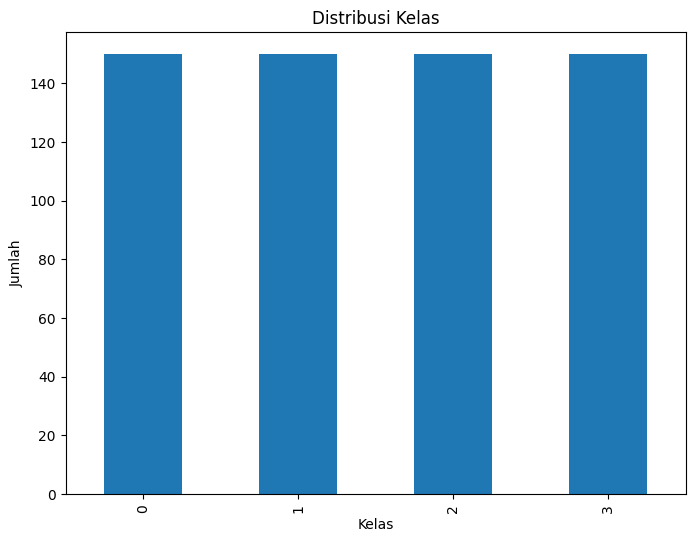

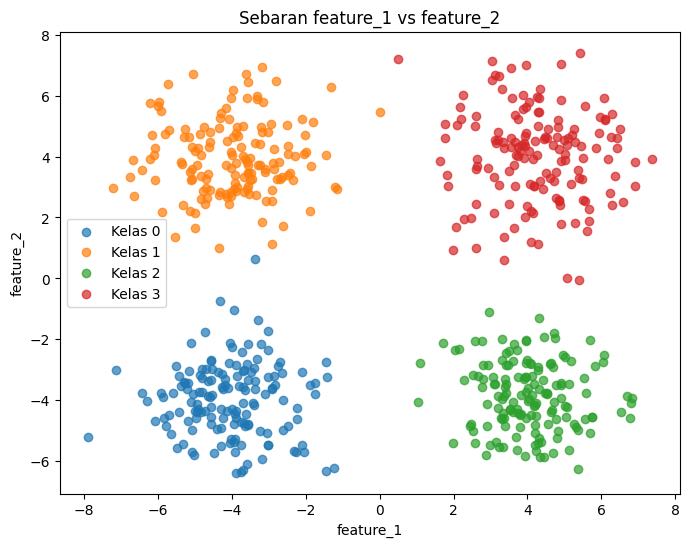

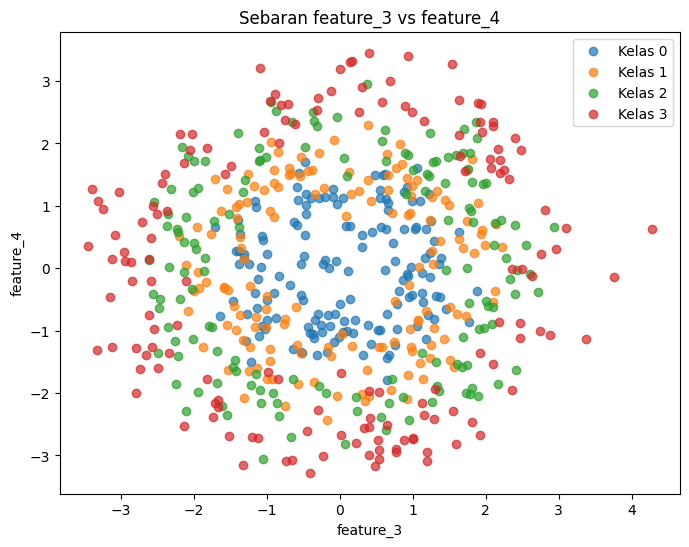

In [ ]:
# Distribusi kelas
class_counts = df["target"].value_counts().sort_index()
ax = class_counts.plot(kind="bar")
ax.set_title("Distribusi Kelas")
ax.set_xlabel("Kelas")
ax.set_ylabel("Jumlah")
plt.show()

# Scatter fitur utama
plt.figure()
for cls in sorted(df["target"].unique()):
    subset = df[df["target"] == cls]
    plt.scatter(subset["feature_1"], subset["feature_2"], label=f"Kelas {cls}", alpha=0.7)
plt.title("Sebaran feature_1 vs feature_2")
plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.legend()
plt.show()

plt.figure()
for cls in sorted(df["target"].unique()):
    subset = df[df["target"] == cls]
    plt.scatter(subset["feature_3"], subset["feature_4"], label=f"Kelas {cls}", alpha=0.7)
plt.title("Sebaran feature_3 vs feature_4")
plt.xlabel("feature_3")
plt.ylabel("feature_4")
plt.legend()
plt.show()

### Jawaban Analisis EDA

Tuliskan minimal 1 paragraf:
- fitur yang paling memisahkan kelas,
- indikasi noise/overlap,
- implikasi awal terhadap Decision Tree dan SVM.

**Jawaban:**  
1. Distribusi target menunjukkan kelas yang seimbang sempurna (150 sampel per kelas). Dari visualisasi scatter plot, feature_1 dan feature_2 tampak sebagai fitur yang paling informatif dan memisahkan kelas dengan sangat baik. Kombinasi kedua fitur ini membentuk empat klaster yang terdefinisi dengan jelas untuk masing-masing kelas target.
2. Scatter plot untuk feature_3 dan feature_4 menunjukkan pola radial atau gelombang dengan tingkat overlap antar kelas yang sangat tinggi dan sulit dipisahkan secara sederhana. Selain itu, sesuai desain pembuatannya, dataset ini juga mengandung noise murni pada feature_5 dan redundansi pada feature_6.
3. Implikasi model
- Untuk Decision Tree, kehadiran feature_1 dan feature_2 sangat menguntungkan karena algoritma ini bekerja dengan memotong ruang fitur secara orthogonal (garis lurus horizontal/vertikal), yang mana sangat ideal untuk memisahkan empat klaster tersebut. Namun, perlu hati-hati dengan fitur noise yang bisa memicu overfitting jika tree dibiarkan tumbuh terlalu dalam tanpa pruning.
- Untuk SVM, karena klaster utamanya sudah terpisah dengan sangat jelas, algoritma SVM Linear diprediksi sudah lebih dari cukup untuk menghasilkan decision boundary yang solid dan akurasi tinggi. Penggunaan SVM dengan Kernel RBF secara teoritis bisa menangkap pola non-linear dari fitur radial yang tumpang tindih, namun mungkin tidak memberikan peningkatan akurasi yang signifikan karena kelas target sudah sangat linearly separable di fitur utamanya.


# 4. Fokus Utama: Pembentukan Decision Tree Manual dengan Entropy dan Information Gain

Bagian ini merupakan komponen utama penilaian. Anda tidak cukup hanya menggunakan `DecisionTreeClassifier`; Anda harus menunjukkan bagaimana tree terbentuk melalui proses matematis.


## 4.1 Subset Data untuk Perhitungan Manual

Gunakan 20 baris sampel agar perhitungan manual dapat ditelusuri. Untuk memudahkan perhitungan, fitur numerik akan didiskritisasi dengan threshold berbasis median/mean.


In [ ]:
df_sample = df.sample(20, random_state=RANDOM_STATE).copy()
df_sample_manual = df_sample[["feature_1", "feature_2", "target"]].reset_index(drop=True)

print("Subset data untuk perhitungan manual:")
display(df_sample_manual)

manual_calculation_done = False
root_node_selected = False
level2_simulation_done = False

Subset data untuk perhitungan manual:


,feature_1,feature_2,target
0,1.864265,3.031329,3
1,-5.016152,-5.817817,0
2,-4.816030,-3.721296,0
3,-3.113461,3.596653,1
4,-3.883507,-2.837626,0
5,-4.585085,4.809705,1
6,2.451737,-4.855598,2
7,-1.153256,2.949212,1
8,4.281633,-2.919040,2
9,4.691642,4.364943,3


## 4.2 Fungsi Entropy dan Information Gain

Lengkapi dan jalankan fungsi berikut. Fungsi ini boleh digunakan untuk membantu perhitungan, tetapi Anda tetap wajib menjelaskan langkahnya secara tertulis.


In [ ]:
def entropy(y):
    """Hitung entropy dari array label kelas."""
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

def information_gain_for_threshold(data, feature, target_col, threshold):
    """Hitung Information Gain untuk split biner feature <= threshold vs > threshold."""
    parent_entropy = entropy(data[target_col].values)

    left = data[data[feature] <= threshold]
    right = data[data[feature] > threshold]

    n = len(data)
    left_weight = len(left) / n
    right_weight = len(right) / n

    weighted_entropy = (
        left_weight * entropy(left[target_col].values) +
        right_weight * entropy(right[target_col].values)
    )

    ig = parent_entropy - weighted_entropy

    return {
        "feature": feature,
        "threshold": threshold,
        "parent_entropy": parent_entropy,
        "left_count": len(left),
        "right_count": len(right),
        "left_entropy": entropy(left[target_col].values),
        "right_entropy": entropy(right[target_col].values),
        "weighted_entropy": weighted_entropy,
        "information_gain": ig
    }

parent_entropy = entropy(df_sample_manual["target"].values)
print(f"Entropy parent = {parent_entropy:.4f}")

Entropy parent = 2.0000


### Jawaban Manual 1: Perhitungan Entropy Parent

Tuliskan distribusi kelas dan perhitungan entropy parent secara bertahap.

Format minimal:
- Jumlah data per kelas
- Probabilitas setiap kelas
- Substitusi ke rumus entropy
- Nilai akhir entropy parent

**Jawaban:**  
- **Jumlah data per kelas**: Total 20 sampel (Subset). Berdasarkan output, dataset terdistribusi merata dengan masing-masing kelas (0, 1, 2, 3) berjumlah 5 sampel.

- **Probabilitas setiap kelas**:

$P(0) = P(1) = P(2) = P(3) = \frac{5}{20} = 0.25$

- **Substitusi ke rumus entropy**:

$E = - \sum (P(i) \cdot \log_2 P(i))$
$E = - 4 \times (0.25 \cdot \log_2 0.25) = -4 \times (0.25 \cdot -2)$

- **Nilai akhir**: $E = 2.0$

Nilai 2.0 adalah nilai entropy maksimum untuk klasifikasi 4 kelas. Hal ini menunjukkan bahwa pada tahap parent node, kondisi data sangat heterogen (kacau) karena tidak ada kelas yang mendominasi, sehingga diperlukan split untuk menurunkan tingkat impurity.

## 4.3 Hitung Information Gain untuk Kandidat Root Node

Gunakan threshold median untuk `feature_1` dan `feature_2`. Kemudian bandingkan Information Gain-nya.


In [ ]:
candidate_results = []

for feature in ["feature_1", "feature_2"]:
    threshold = df_sample_manual[feature].median()
    result = information_gain_for_threshold(
        data=df_sample_manual,
        feature=feature,
        target_col="target",
        threshold=threshold
    )
    candidate_results.append(result)

ig_table = pd.DataFrame(candidate_results)
display(ig_table)

best_root = ig_table.sort_values("information_gain", ascending=False).iloc[0]
print("Kandidat root node terbaik:")
display(best_root)

root_node_selected = True

,feature,threshold,parent_entropy,left_count,right_count,left_entropy,right_entropy,weighted_entropy,information_gain
0,feature_1,0.355504,2.0,10,10,1.0,1.0,1.0,1.0
1,feature_2,0.069036,2.0,10,10,1.0,1.0,1.0,1.0


Kandidat root node terbaik:


,0
feature,feature_1
threshold,0.355504
parent_entropy,2.0
left_count,10
right_count,10
left_entropy,1.0
right_entropy,1.0
weighted_entropy,1.0
information_gain,1.0


### Jawaban Manual 2: Pemilihan Root Node

Jelaskan:
1. Threshold yang digunakan untuk setiap fitur.
2. Entropy kiri dan kanan pada setiap fitur.
3. Information Gain setiap fitur.
4. Fitur mana yang dipilih sebagai root node dan mengapa.

**Jawaban:**  
1. **Threshold**: feature_1 menggunakan threshold 0.3555, sedangkan feature_2 menggunakan threshold 0.0690.
2. **Entropy Kiri dan Kanan**: Untuk kedua fitur, hasil split menghasilkan 10 sampel di cabang kiri dengan entropy 1.0, dan 10 sampel di cabang kanan dengan entropy 1.0.
3. **Information Gain**: Keduanya menghasilkan IG maksimal yaitu 1.0 (didapat dari $Entropy Parent (2.0) - Weighted Entropy Child (1.0)$).
4. **Pemilihan Root Node**: feature_1 dipilih sebagai root node. Secara matematis, feature_1 dan feature_2 memberikan penurunan impurity (Information Gain) yang sama besar. Dalam kondisi seperti ini, algoritma umumnya memilih fitur yang dievaluasi lebih dulu. Penurunan entropy dari 2.0 menjadi 1.0 membuktikan fitur ini sangat kuat membagi ruang sampel 4 kelas menjadi dua sub-ruang yang masing-masing hanya berisi 2 kelas.

## 4.4 Simulasi Split Level 2

Setelah root node dipilih, pilih salah satu cabang hasil split dan lakukan split lanjutan menggunakan fitur yang belum menjadi root. Hitung kembali entropy dan information gain untuk cabang tersebut.


In [ ]:
root_feature = best_root["feature"]
root_threshold = best_root["threshold"]

left_branch = df_sample_manual[df_sample_manual[root_feature] <= root_threshold].copy()
right_branch = df_sample_manual[df_sample_manual[root_feature] > root_threshold].copy()

print(f"Root: {root_feature} <= {root_threshold:.4f}")
print(f"Jumlah data left branch: {len(left_branch)}")
print(f"Jumlah data right branch: {len(right_branch)}")

# Pilih cabang dengan entropy lebih tinggi untuk split lanjutan karena masih lebih heterogen
left_entropy = entropy(left_branch["target"].values)
right_entropy = entropy(right_branch["target"].values)

branch_to_split = left_branch if left_entropy >= right_entropy else right_branch
branch_name = "left" if left_entropy >= right_entropy else "right"

remaining_features = [f for f in ["feature_1", "feature_2"] if f != root_feature]
level2_results = []

for feature in remaining_features:
    threshold = branch_to_split[feature].median()
    level2_results.append(information_gain_for_threshold(
        data=branch_to_split,
        feature=feature,
        target_col="target",
        threshold=threshold
    ))

level2_table = pd.DataFrame(level2_results)
display(level2_table)

level2_simulation_done = True

Root: feature_1 <= 0.3555
Jumlah data left branch: 10
Jumlah data right branch: 10


,feature,threshold,parent_entropy,left_count,right_count,left_entropy,right_entropy,weighted_entropy,information_gain
0,feature_2,0.055793,1.0,5,5,-0.0,-0.0,-0.0,1.0


### Jawaban Manual 3: Simulasi Tree Level 2

Jelaskan:
1. Cabang mana yang dipilih untuk split lanjutan dan alasannya.
2. Nilai entropy cabang tersebut sebelum split.
3. Hasil Information Gain pada level 2.
4. Bentuk tree sementara yang Anda peroleh.

Contoh bentuk tree:

```text
Root: feature_x <= threshold
├── Cabang kiri: ...
└── Cabang kanan:
    ├── ...
    └── ...
```

**Jawaban:**  
1. **Cabang yang dipilih**: Cabang kiri (feature_1 <= 0.3555). Alasannya, cabang ini masih memiliki entropy > 0 (yakni 1.0), yang menandakan datanya masih heterogen (memuat kelas 0 dan 1) dan belum pure, sehingga wajib dilakukan split lanjutan.
2. **Nilai entropi sebelum split**: 1.0
3. **Information Gain Level 2**: Menggunakan feature_2 <= 0.0558, diperoleh Information Gain sebesar 1.0. Split ini memisahkan 5 sampel kelas 0 ke kiri dan 5 sampel kelas 1 ke kanan, menjadikan entropy kedua child node menjadi 0.0 (homogen sempurna).
4. **Bentuk tree sementara**:
```text
Root: feature_1 <= 0.3555 (Entropy: 2.0)
├── Cabang kiri: feature_2 <= 0.0558 (Entropy: 1.0)
│   ├── Kiri: Class 0 (Entropy: 0.0, Samples: 5)
│   └── Kanan: Class 1 (Entropy: 0.0, Samples: 5)
└── Cabang kanan: (Belum di-split)
```

## 4.5 Bandingkan Perhitungan Manual dengan Decision Tree dari scikit-learn

Latih Decision Tree kecil menggunakan dua fitur yang sama (`feature_1`, `feature_2`) dan `criterion='entropy'`.


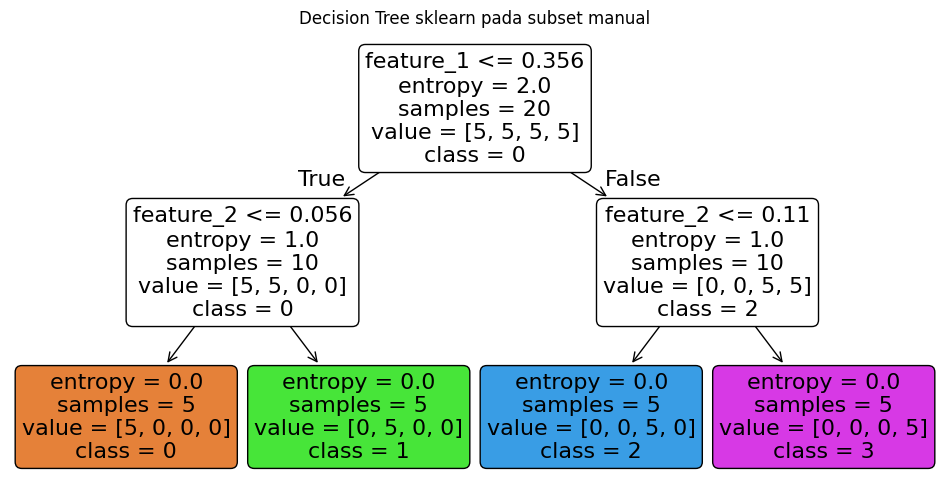

|--- feature_1 <= 0.36
|   |--- feature_2 <= 0.06
|   |   |--- class: 0
|   |--- feature_2 >  0.06
|   |   |--- class: 1
|--- feature_1 >  0.36
|   |--- feature_2 <= 0.11
|   |   |--- class: 2
|   |--- feature_2 >  0.11
|   |   |--- class: 3



In [ ]:
X_manual = df_sample_manual[["feature_1", "feature_2"]]
y_manual = df_sample_manual["target"]

dt_manual_compare = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    random_state=RANDOM_STATE
)
dt_manual_compare.fit(X_manual, y_manual)

plt.figure(figsize=(12, 6))
plot_tree(
    dt_manual_compare,
    feature_names=["feature_1", "feature_2"],
    class_names=[str(c) for c in sorted(y_manual.unique())],
    filled=True,
    rounded=True
)
plt.title("Decision Tree sklearn pada subset manual")
plt.show()

print(export_text(dt_manual_compare, feature_names=["feature_1", "feature_2"].copy()))

### Jawaban Manual 4: Perbandingan Manual vs scikit-learn

Jawab secara kritis:
1. Apakah root node manual sama dengan root node scikit-learn?
2. Jika berbeda, jelaskan kemungkinan penyebabnya.
3. Mengapa threshold scikit-learn dapat berbeda dari median?
4. Apa kelebihan dan keterbatasan perhitungan manual?

**Jawaban:**  
1. Ya, root node yang terpilih sama, yaitu menggunakan feature_1. Perbedaan angka (0.3555 pada manual vs 0.356 pada scikit-learn) hanyalah masalah pembulatan representasi visual pada plot tree.
2. Pada kondisi di mana Information Gain antara dua fitur bernilai persis sama (seperti pada level 1), perhitungan manual mungkin memilih fitur secara berurutan. Di sisi lain, implementasi scikit-learn (CART) sangat dipengaruhi oleh parameter random_state untuk memecah kondisi seri (tie-breaking).
3. Perhitungan manual disimplifikasi dengan median sebagai titik potong. Algoritma scikit-learn mengevaluasi seluruh kemungkinan threshold di antara titik-titik data yang berurutan secara komputasional untuk mencari pemisahan optimal (Information Gain paling maksimal).
4. Kelebihannya adalah memberikan pemahaman white-box yang fundamental secara matematis mengenai bagaimana impurity (seperti entropy) direduksi pada setiap node. Sedangkan keterbatasannya sangat tidak efisien dan mahal secara komputasi untuk dataset berdimensi besar dengan fitur kontinu, karena mustahil menguji setiap kemungkinan nilai threshold tanpa otomatisasi.

In [ ]:
# Tandai bagian manual selesai setelah seluruh tabel utama dihasilkan
required_cols = {"feature", "threshold", "parent_entropy", "left_entropy", "right_entropy", "weighted_entropy", "information_gain"}
assert required_cols.issubset(set(ig_table.columns)), "Tabel Information Gain root belum lengkap."
assert len(ig_table) >= 2, "Minimal dua kandidat fitur harus dihitung."
assert root_node_selected is True, "Root node belum dipilih."
assert level2_simulation_done is True, "Simulasi level 2 belum dilakukan."

manual_calculation_done = True
print("Bagian Decision Tree manual telah selesai secara teknis.")

Bagian Decision Tree manual telah selesai secara teknis.


# 5. Split Data dan Preprocessing

Catatan penting:
- Decision Tree tidak wajib scaling karena berbasis split threshold.
- SVM sensitif terhadap skala fitur sehingga wajib menggunakan `StandardScaler`.


In [ ]:
X_full = df.drop(columns=["target"])
y_full = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.25,
    stratify=y_full,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)

(450, 6) (150, 6)


# 6. Implementasi Decision Tree

Eksperimen minimal:
1. Decision Tree default/awal.
2. Decision Tree dengan pengendalian kompleksitas, misalnya `max_depth`, `min_samples_leaf`, atau `ccp_alpha`.


Accuracy Decision Tree awal: 0.9933333333333333
Accuracy Decision Tree terkendali: 0.9933333333333333


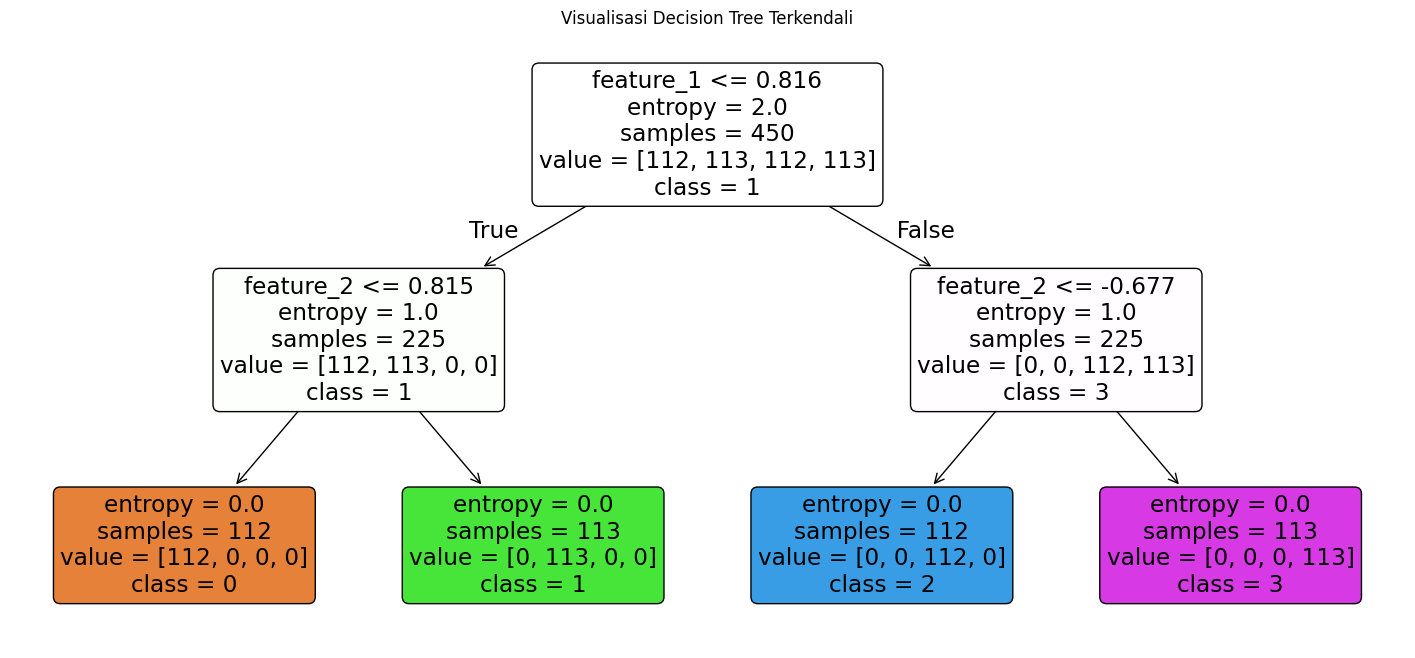

,feature,importance
0,feature_1,0.500004
1,feature_2,0.499996
2,feature_3,0.000000
3,feature_4,0.000000
4,feature_5,0.000000
5,feature_6,0.000000


In [ ]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=None,
    random_state=RANDOM_STATE
)
dt_model.fit(X_train, y_train)

dt_pruned = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_leaf=8,
    random_state=RANDOM_STATE
)
dt_pruned.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_pruned_pred = dt_pruned.predict(X_test)

print("Accuracy Decision Tree awal:", accuracy_score(y_test, dt_pred))
print("Accuracy Decision Tree terkendali:", accuracy_score(y_test, dt_pruned_pred))

plt.figure(figsize=(18, 8))
plot_tree(
    dt_pruned,
    feature_names=X_full.columns,
    class_names=[str(c) for c in sorted(y_full.unique())],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Visualisasi Decision Tree Terkendali")
plt.show()

feature_importance = pd.DataFrame({
    "feature": X_full.columns,
    "importance": dt_pruned.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance)

### Jawaban Analisis Decision Tree

Tuliskan:
1. Apakah Decision Tree awal menunjukkan indikasi overfitting?
2. Bagaimana pengaruh `max_depth` dan `min_samples_leaf`?
3. Fitur apa yang paling penting menurut model?
4. Hubungkan hasil ini dengan konsep Information Gain.

**Jawaban:**  

1. Decision Tree awal dengan parameter max_depth=None secara algoritma selalu berisiko mengalami overfitting. Model akan terus menumbuhkan branch hingga setiap leaf mencapai entropy 0.0 (murni), yang berpotensi ikut mempelajari noise dari feature_5 atau pola non-linear dari fitur 3 dan 4.

2. Penggunaan max_depth=4 dan min_samples_leaf=8 adalah pre-pruning yang efektif. Ini membatasi kompleksitas model sehingga menghasilkan pohon keputusan yang sangat ringkas dan mudah diinterpretasikan, sekaligus tetap mempertahankan akurasi (0.9933).

3. Model mengonfirmasi hasil eksplorasi data, feature_1 (0.500004) dan feature_2 (0.499996) merupakan fitur paling krusial, mendominasi 100% tingkat kepentingan (importance).

4. Algoritma Decision Tree bersifat greedy, feature importance dihitung berdasarkan akumulasi penurunan impurity (Information Gain) dari sebuah fitur. Karena feature_1 dan feature_2 sudah terbukti mampu membelah klaster data secara sempurna hingga leaf node mencapai keadaan pure (entropy = 0.0), model mengabaikan sisa fitur lainnya (IG fitur lain dianggap tidak signifikan atau 0.0).

# 7. Implementasi SVM — Eksperimen Kernel Linear vs RBF

Bagian ini diperbarui agar perbedaan kernel **linear** dan **RBF** tampak jelas secara visual dan empiris.

Anda harus mengerjakan dua jalur eksperimen:

1. **Dataset utama multi-class**: digunakan untuk evaluasi akhir bersama Decision Tree.
2. **Dataset demonstrasi non-linear multi-class 2D**: digunakan khusus untuk membuktikan kapan kernel RBF lebih unggul daripada kernel linear.

Fokus analisis:
- Mengapa kernel linear gagal pada pola non-linear?
- Bagaimana RBF membentuk decision boundary yang melengkung?
- Bagaimana pengaruh `gamma` terhadap underfitting dan overfitting?
- Apakah RBF selalu lebih baik daripada linear?


In [ ]:
# ===== 7.1 SVM pada dataset utama =====
svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1, random_state=RANDOM_STATE))
])

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma="scale", random_state=RANDOM_STATE))
])

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

svm_linear_pred = svm_linear.predict(X_test)
svm_rbf_pred = svm_rbf.predict(X_test)

print("Accuracy SVM Linear pada dataset utama:", accuracy_score(y_test, svm_linear_pred))
print("Accuracy SVM RBF pada dataset utama:", accuracy_score(y_test, svm_rbf_pred))

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.1, 1, 10]
}

svm_grid = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=RANDOM_STATE))
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy"
)
svm_grid.fit(X_train, y_train)

print("Best params SVM RBF:", svm_grid.best_params_)
print("Best CV score SVM RBF:", svm_grid.best_score_)
svm_best_pred = svm_grid.predict(X_test)
print("Accuracy SVM RBF tuned:", accuracy_score(y_test, svm_best_pred))


Accuracy SVM Linear pada dataset utama: 1.0
Accuracy SVM RBF pada dataset utama: 1.0
Best params SVM RBF: {'model__C': 10, 'model__gamma': 'scale'}
Best CV score SVM RBF: 1.0
Accuracy SVM RBF tuned: 0.9933333333333333


## 7.2 Dataset Demonstrasi Non-linear Multi-Class

Dataset berikut dibuat khusus agar mahasiswa dapat melihat perbedaan kernel secara jelas. Bentuk kelas berupa **cincin konsentris** sehingga pemisahan linear sulit dilakukan, sedangkan RBF mampu membuat boundary melengkung.

Dataset ini bukan pengganti dataset utama, melainkan **alat pembuktian visual** untuk memahami perilaku kernel.


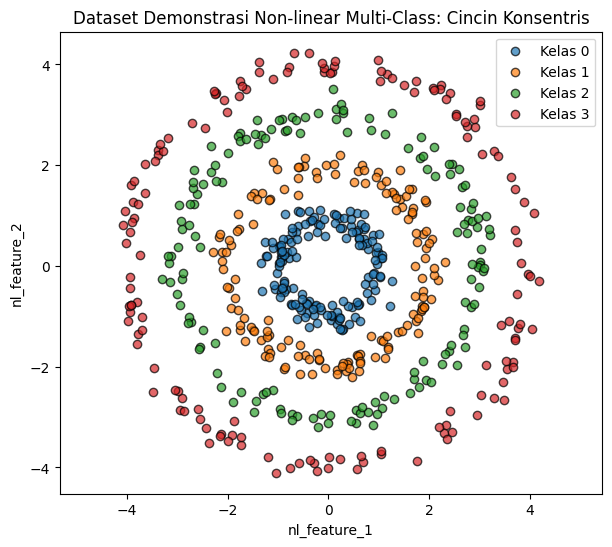

Jumlah kelas: 4
Distribusi kelas:


,count
target,
0,150
1,150
2,150
3,150


In [ ]:
# ===== 7.2 Generate dataset non-linear multi-class 2D =====
rng = np.random.default_rng(RANDOM_STATE)
n_per_class = 150
radii = [1.0, 2.0, 3.0, 4.0]

X_nl_parts = []
y_nl_parts = []

for class_id, r_center in enumerate(radii):
    theta = rng.uniform(0, 2*np.pi, n_per_class)
    r = rng.normal(loc=r_center, scale=0.16, size=n_per_class)
    x1 = r * np.cos(theta)
    x2 = r * np.sin(theta)
    X_nl_parts.append(np.column_stack([x1, x2]))
    y_nl_parts.append(np.full(n_per_class, class_id))

X_nl = np.vstack(X_nl_parts)
y_nl = np.concatenate(y_nl_parts)

# Acak urutan data
perm = rng.permutation(len(y_nl))
X_nl = X_nl[perm]
y_nl = y_nl[perm]

X_nl_df = pd.DataFrame(X_nl, columns=["nl_feature_1", "nl_feature_2"])
y_nl_series = pd.Series(y_nl, name="target")

plt.figure(figsize=(7, 6))
for cls in sorted(np.unique(y_nl)):
    subset = X_nl_df[y_nl_series == cls]
    plt.scatter(subset["nl_feature_1"], subset["nl_feature_2"], label=f"Kelas {cls}", alpha=0.7, edgecolor="k")
plt.title("Dataset Demonstrasi Non-linear Multi-Class: Cincin Konsentris")
plt.xlabel("nl_feature_1")
plt.ylabel("nl_feature_2")
plt.legend()
plt.axis("equal")
plt.show()

print("Jumlah kelas:", len(np.unique(y_nl)))
print("Distribusi kelas:")
display(y_nl_series.value_counts().sort_index())


## 7.3 Fungsi Visualisasi Decision Boundary 2D

Fungsi berikut wajib digunakan untuk membandingkan kernel linear dan RBF secara berdampingan.


In [ ]:
def plot_decision_boundary_2d(model, X, y, title):
    """Plot decision boundary untuk data 2D berbentuk DataFrame atau array."""
    if isinstance(X, pd.DataFrame):
        X_values = X.values
        col_names = list(X.columns)
        grid_to_model = "dataframe"
    else:
        X_values = np.asarray(X)
        col_names = ["feature_1", "feature_2"]
        grid_to_model = "array"

    x_min, x_max = X_values[:, 0].min() - 0.8, X_values[:, 0].max() + 0.8
    y_min, y_max = X_values[:, 1].min() - 0.8, X_values[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350)
    )

    grid_array = np.c_[xx.ravel(), yy.ravel()]
    if grid_to_model == "dataframe":
        grid = pd.DataFrame(grid_array, columns=col_names)
    else:
        grid = grid_array

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.25)
    for cls in sorted(np.unique(y)):
        subset = X_values[np.asarray(y) == cls]
        plt.scatter(subset[:, 0], subset[:, 1], label=f"Kelas {cls}", alpha=0.78, edgecolor="k")
    plt.title(title)
    plt.xlabel(col_names[0])
    plt.ylabel(col_names[1])
    plt.legend()
    plt.axis("equal")
    plt.show()


## 7.4 Perbandingan Linear vs RBF pada Dataset Non-linear

Eksperimen ini wajib memperlihatkan bahwa:
- SVM Linear membentuk batas keputusan relatif lurus sehingga sulit memisahkan kelas berbentuk cincin.
- SVM RBF mampu membentuk batas keputusan non-linear yang mengikuti struktur data.


Accuracy SVM Linear pada dataset non-linear: 0.32
Accuracy SVM RBF pada dataset non-linear: 0.9933333333333333


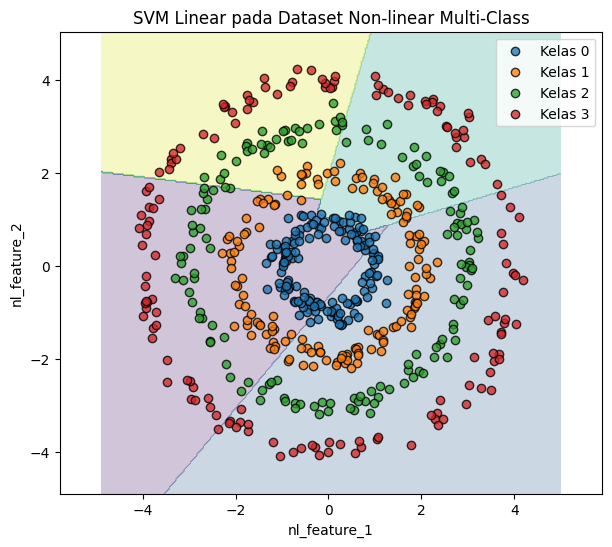

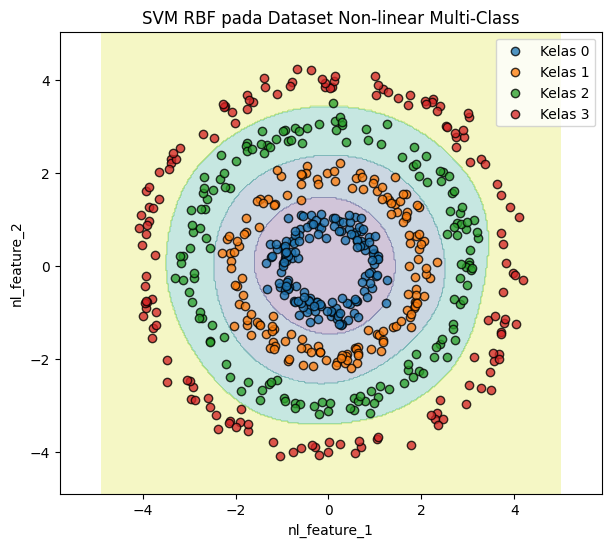

In [ ]:
# ===== 7.4 Train/test split untuk dataset non-linear =====
X_nl_train, X_nl_test, y_nl_train, y_nl_test = train_test_split(
    X_nl_df,
    y_nl_series,
    test_size=0.25,
    stratify=y_nl_series,
    random_state=RANDOM_STATE
)

svm_linear_nl = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1, random_state=RANDOM_STATE))
])

svm_rbf_nl = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma=1, random_state=RANDOM_STATE))
])

svm_linear_nl.fit(X_nl_train, y_nl_train)
svm_rbf_nl.fit(X_nl_train, y_nl_train)

svm_linear_nl_pred = svm_linear_nl.predict(X_nl_test)
svm_rbf_nl_pred = svm_rbf_nl.predict(X_nl_test)

print("Accuracy SVM Linear pada dataset non-linear:", accuracy_score(y_nl_test, svm_linear_nl_pred))
print("Accuracy SVM RBF pada dataset non-linear:", accuracy_score(y_nl_test, svm_rbf_nl_pred))

plot_decision_boundary_2d(svm_linear_nl, X_nl_df, y_nl_series, "SVM Linear pada Dataset Non-linear Multi-Class")
plot_decision_boundary_2d(svm_rbf_nl, X_nl_df, y_nl_series, "SVM RBF pada Dataset Non-linear Multi-Class")


## 7.5 Eksperimen Gamma pada Kernel RBF

Jalankan seluruh nilai `gamma` berikut. Amati perubahan boundary:
- `gamma` sangat kecil → boundary terlalu halus, cenderung underfitting, kadang terlihat mirip linear.
- `gamma` sedang → boundary mengikuti struktur non-linear secara wajar.
- `gamma` terlalu besar → boundary sangat lokal dan berisiko overfitting.


Gamma = 0.01 | Accuracy = 0.2600


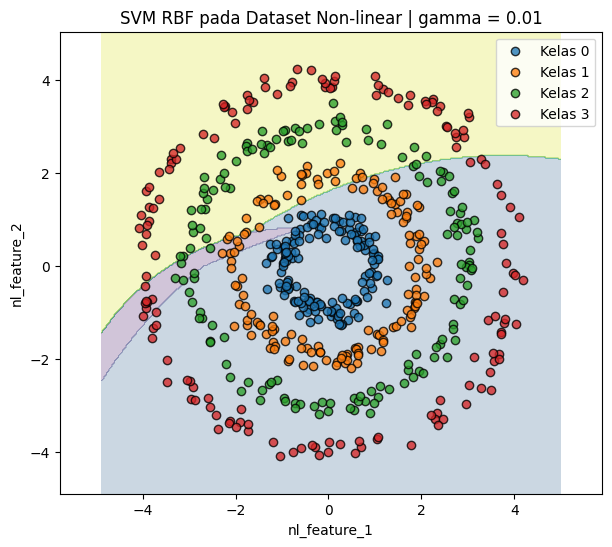

Gamma = 0.1 | Accuracy = 0.9133


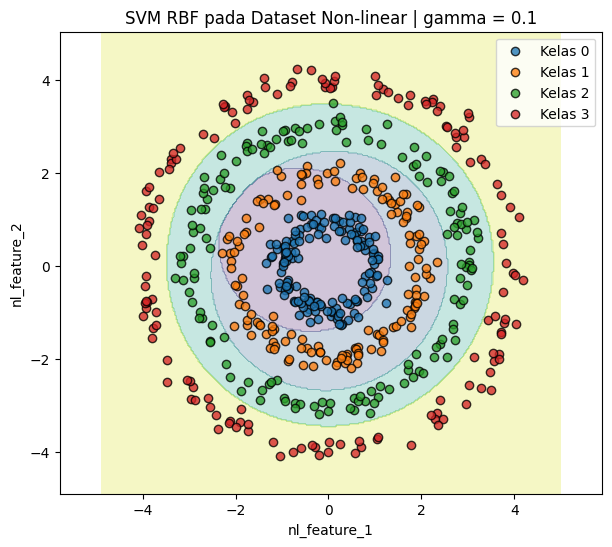

Gamma = 1 | Accuracy = 0.9933


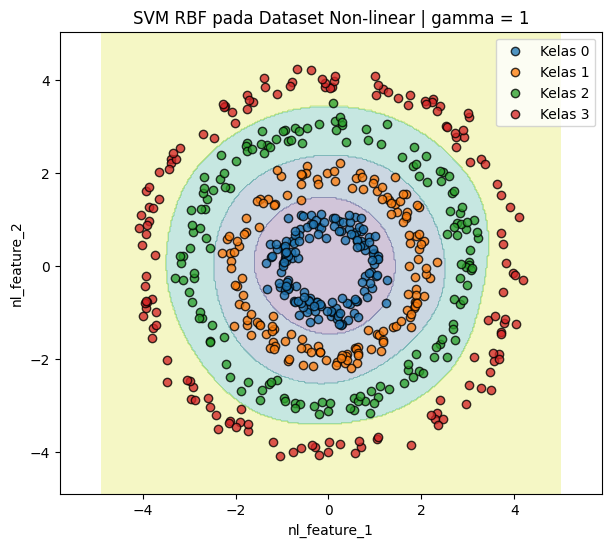

Gamma = 10 | Accuracy = 0.9933


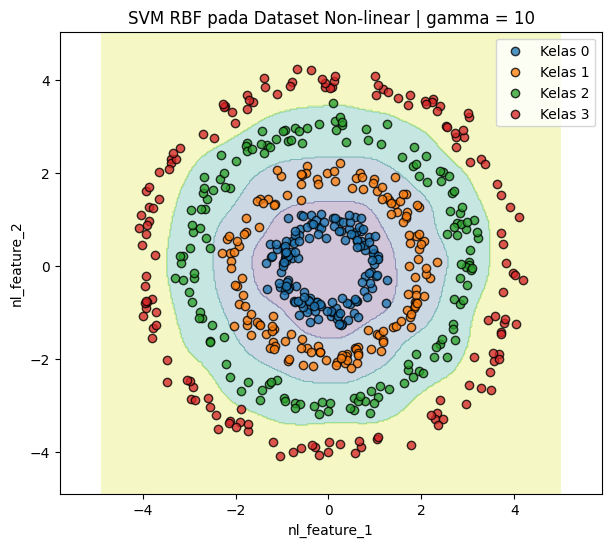

Gamma = 50 | Accuracy = 0.9933


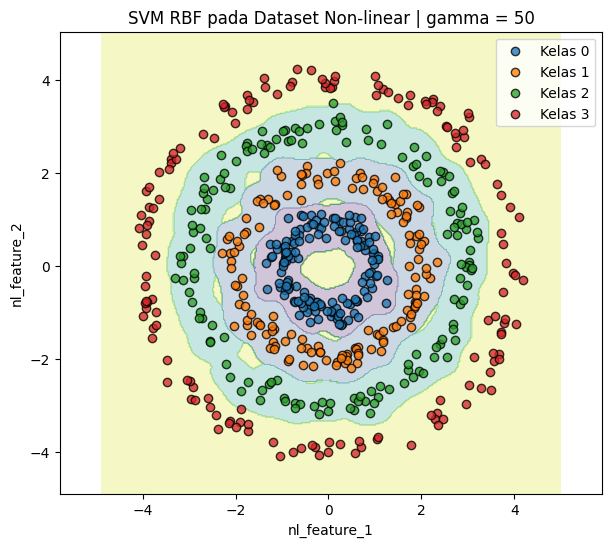

,gamma,accuracy
0,0.01,0.260000
1,0.10,0.913333
2,1.00,0.993333
3,10.00,0.993333
4,50.00,0.993333


In [ ]:
# ===== 7.5 Eksperimen gamma wajib =====
gamma_values = [0.01, 0.1, 1, 10, 50]
gamma_experiment_results = []

for gamma_value in gamma_values:
    model_gamma = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1, gamma=gamma_value, random_state=RANDOM_STATE))
    ])
    model_gamma.fit(X_nl_train, y_nl_train)
    pred_gamma = model_gamma.predict(X_nl_test)
    acc_gamma = accuracy_score(y_nl_test, pred_gamma)
    gamma_experiment_results.append({
        "gamma": gamma_value,
        "accuracy": acc_gamma
    })

    print(f"Gamma = {gamma_value} | Accuracy = {acc_gamma:.4f}")
    plot_decision_boundary_2d(
        model_gamma,
        X_nl_df,
        y_nl_series,
        f"SVM RBF pada Dataset Non-linear | gamma = {gamma_value}"
    )

gamma_results_df = pd.DataFrame(gamma_experiment_results)
display(gamma_results_df)


### Jawaban Analisis SVM — Wajib Diisi

Jawab berdasarkan **hasil plot dan metrik**, bukan hanya teori umum.

1. Pada dataset non-linear multi-class, mengapa SVM Linear sulit memisahkan kelas?
2. Bagaimana bentuk decision boundary SVM RBF dibandingkan SVM Linear?
3. Pada nilai `gamma` berapa model tampak underfitting? Jelaskan berdasarkan plot.
4. Pada nilai `gamma` berapa model berisiko overfitting? Jelaskan berdasarkan plot.
5. Tunjukkan kondisi ketika RBF tampak mirip linear. Apa penyebabnya?
6. Apakah RBF selalu lebih baik daripada linear? Jelaskan dengan mengacu pada dataset utama dan dataset non-linear.

**Jawaban:**  
1. SVM Linear bekerja dengan mencari hyperplane berupa garis lurus datar untuk memisahkan kelas. Pada pola cincin konsentris, kelas tidak linearly separable, tidak ada satupun garis lurus yang bisa memisahkan cincin tanpa memotong kelas lainnya, yang berujung pada akurasi hancur (0.32).
2. Berkat kernel trick, SVM RBF mentransformasikan data ke dimensi yang lebih tinggi sehingga mampu memproyeksikan batas keputusan melengkung yang mulus mengikuti pola sirkular data. Sebaliknya, SVM Linear hanya mampu memotong lurus (membentuk sudut tajam antar area keputusan).
3. Pada gamma = 0.01 (akurasi 0.26). Nilai gamma yang terlalu kecil membuat radius pengaruh dari support vectors sangat luas, sehingga batas keputusannya menjadi terlalu rileks/halus, tidak mampu menangkap lengkungan cincin, dan gagal membedakan kelas.
4. Pada gamma = 50 (akurasi 0.9933). Walaupun akurasinya tinggi di test set, plot menunjukkan decision boundary membungkus setiap titik data latih dengan sangat ketat (membentuk pulau-pulau kecil). Margin ini terlalu sempit dan akan sangat rentan gagal jika ada data baru yang sedikit bergeser.
5. Pada nilai gamma = 0.01. Saat pengaruh setiap titik dianggap menjangkau keseluruhan ruang fitur (radius tak hingga), RBF kehilangan sensitivitas terhadap struktur lokal dan perilakunya terdegradasi menjadi menyerupai SVM Linear (garis lurus/halus).
6. Tidak. Pada dataset utama yang klasternya terpisah jelas secara orthogonal/linear, SVM Linear sudah memberikan akurasi sempurna (1.0) dengan biaya komputasi yang lebih ringan. RBF hanya mutlak diperlukan jika struktur fitur sangat non-linear dan overlapping seperti pada dataset demonstrasi cincin.


# 8. Evaluasi Model

,model,accuracy
2,SVM Linear,1.000000
3,SVM RBF,1.000000
0,Decision Tree Awal,0.993333
1,Decision Tree Terkendali,0.993333
4,SVM RBF Tuned,0.993333



Decision Tree Awal
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        38
           3       1.00      0.97      0.99        37

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



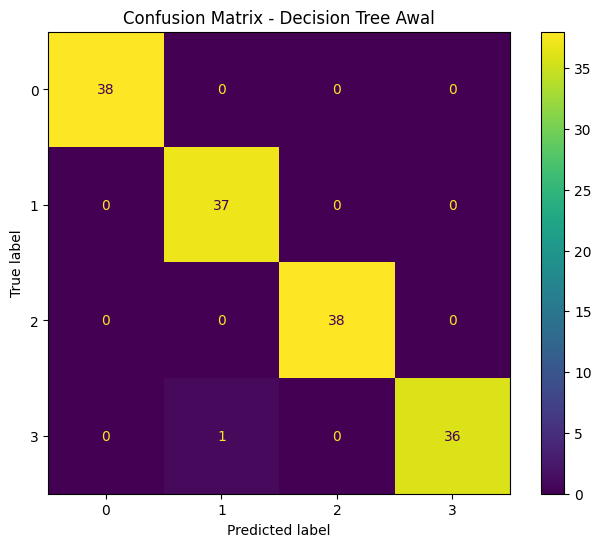


Decision Tree Terkendali
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        38
           3       1.00      0.97      0.99        37

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



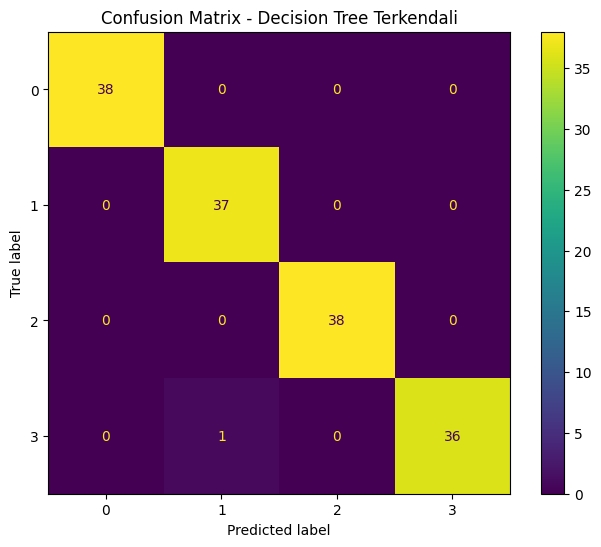


SVM Linear
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00        37

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



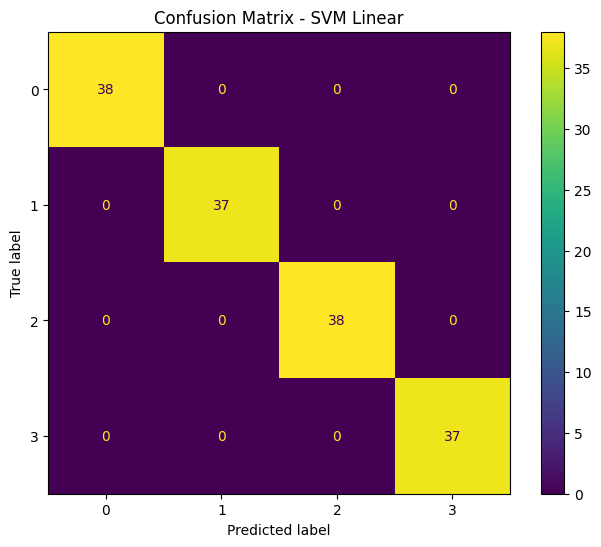


SVM RBF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00        37

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



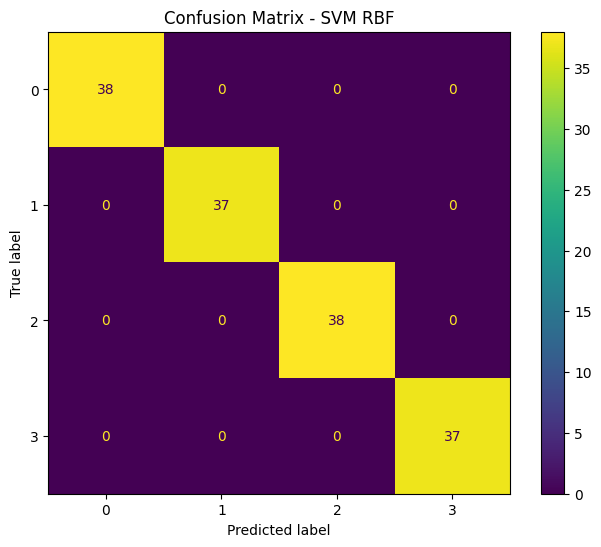


SVM RBF Tuned
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      0.97      0.99        38
           3       0.97      1.00      0.99        37

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



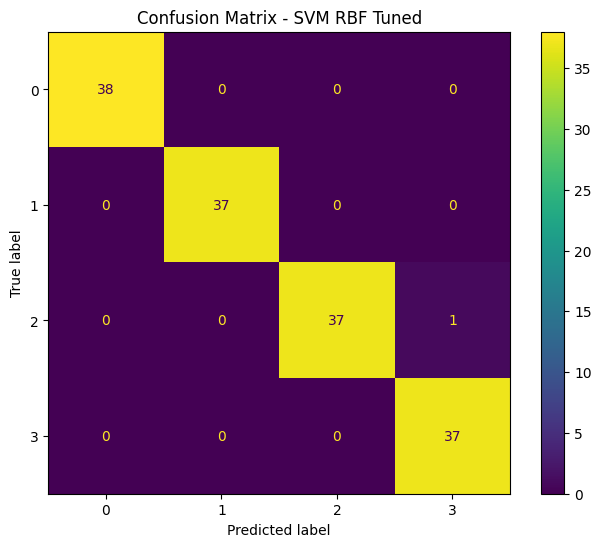

In [ ]:
models = {
    "Decision Tree Awal": (dt_model, dt_pred),
    "Decision Tree Terkendali": (dt_pruned, dt_pruned_pred),
    "SVM Linear": (svm_linear, svm_linear_pred),
    "SVM RBF": (svm_rbf, svm_rbf_pred),
    "SVM RBF Tuned": (svm_grid, svm_best_pred),
}

summary = []
for name, (model, pred) in models.items():
    summary.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred)
    })

summary_df = pd.DataFrame(summary).sort_values("accuracy", ascending=False)
display(summary_df)

for name, (model, pred) in models.items():
    print("\n", "="*70)
    print(name)
    print(classification_report(y_test, pred))
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

### Jawaban Analisis Evaluasi

Tuliskan:
1. Model mana yang paling baik berdasarkan accuracy dan classification report?
2. Kelas mana yang paling sering keliru diklasifikasikan?
3. Apakah accuracy saja cukup? Jelaskan.
4. Apakah model terbaik juga paling mudah dijelaskan?

**Jawaban:**  
1. Pada dataset utama, SVM Linear dan SVM RBF adalah yang terbaik dengan akurasi absolut (1.00) dan f1-score sempurna di semua kelas.
2. Pada model Decision Tree (baik Awal maupun Terkendali), terdapat satu kesalahan konsisten: 1 sampel kelas 3 diprediksi salah sebagai kelas 1.
3. Akurasi saja tidak cukup. Meskipun metrik ini terlihat bagus karena distribusi dataset kita seimbang (150 sampel per kelas), untuk melihat performa model seutuhnya, kita wajib mengevaluasi Confusion Matrix dan F1-Score guna mengidentifikasi tipe error (seperti kelemahan model dalam membedakan kelas 3 dan 1).
4. Tidak. SVM memiliki performa 1.00 tetapi bekerja seperti black-box di ruang dimensi tinggi yang sulit divisualisasikan. Sebaliknya, Decision Tree (0.9933) sedikit lebih rendah akurasinya, tetapi jauh lebih transparan karena aturan keputusannya berbentuk aturan logika bersyarat (if-else) yang intuitif.

# 9. Visualisasi Decision Boundary Terpadu

Bagian ini merangkum visualisasi boundary pada dua konteks:

1. **Dataset utama dengan `feature_1` dan `feature_2`** untuk membandingkan Decision Tree, SVM Linear, dan SVM RBF pada data multi-class utama.
2. **Dataset non-linear multi-class** yang sudah divisualisasikan pada Bagian 7 untuk memperlihatkan perbedaan kernel linear dan RBF secara lebih tegas.

Catatan: visualisasi 2D hanya memakai dua fitur, sehingga tidak selalu merepresentasikan keseluruhan performa model pada semua fitur.


Dataset utama 2D:
Accuracy DT 2D: 0.9933333333333333
Accuracy SVM Linear 2D: 0.9933333333333333
Accuracy SVM RBF 2D: 1.0


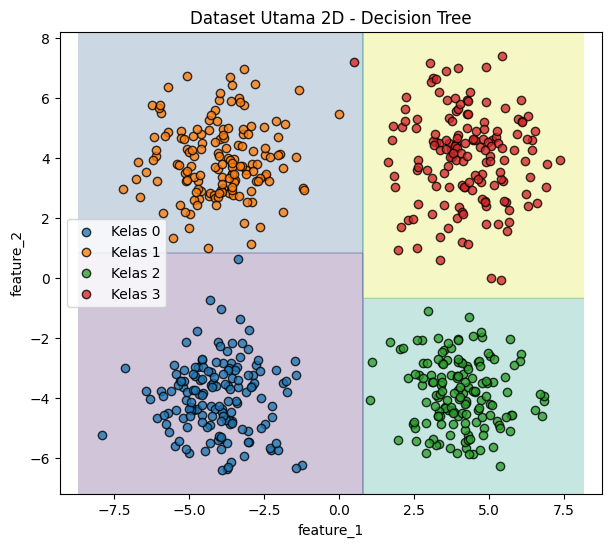

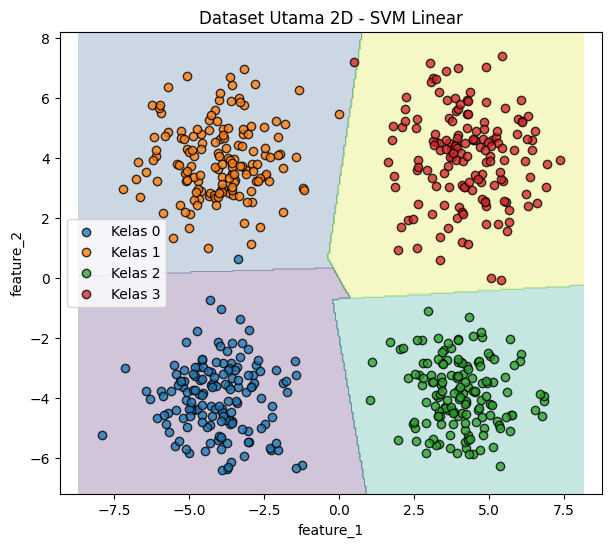

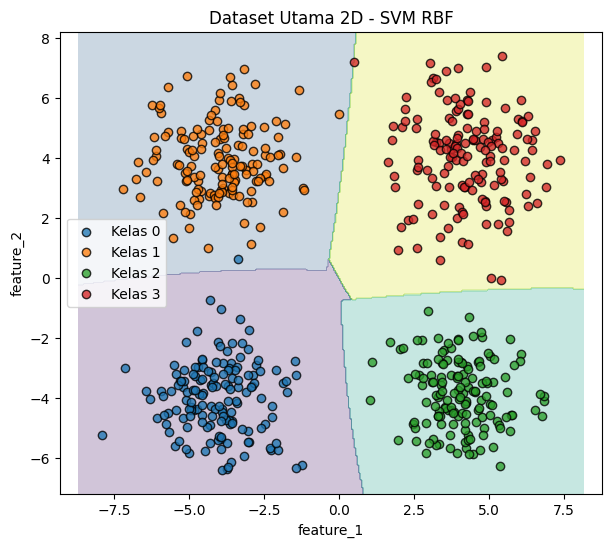

In [ ]:
# ===== 9.1 Decision boundary pada dataset utama menggunakan feature_1 dan feature_2 =====
X2 = df[["feature_1", "feature_2"]]
y2 = df["target"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.25,
    stratify=y2,
    random_state=RANDOM_STATE
)

dt_2d = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=RANDOM_STATE
)
dt_2d.fit(X2_train, y2_train)

svm_linear_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1, random_state=RANDOM_STATE))
])
svm_linear_2d.fit(X2_train, y2_train)

svm_rbf_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma="scale", random_state=RANDOM_STATE))
])
svm_rbf_2d.fit(X2_train, y2_train)

print("Dataset utama 2D:")
print("Accuracy DT 2D:", accuracy_score(y2_test, dt_2d.predict(X2_test)))
print("Accuracy SVM Linear 2D:", accuracy_score(y2_test, svm_linear_2d.predict(X2_test)))
print("Accuracy SVM RBF 2D:", accuracy_score(y2_test, svm_rbf_2d.predict(X2_test)))

plot_decision_boundary_2d(dt_2d, X2, y2, "Dataset Utama 2D - Decision Tree")
plot_decision_boundary_2d(svm_linear_2d, X2, y2, "Dataset Utama 2D - SVM Linear")
plot_decision_boundary_2d(svm_rbf_2d, X2, y2, "Dataset Utama 2D - SVM RBF")

# Variabel penanda untuk validasi otomatis
boundary_visualization_done = True
svm_kernel_comparison_done = True


### Jawaban Analisis Decision Boundary

Tuliskan analisis berbasis plot:

1. Pada dataset utama 2D, apakah boundary SVM RBF berbeda jauh dari SVM Linear? Mengapa?
2. Pada dataset non-linear multi-class, mengapa perbedaan Linear dan RBF tampak lebih jelas?
3. Bagaimana bentuk decision boundary Decision Tree dibandingkan SVM?
4. Jelaskan hubungan antara bentuk boundary, karakteristik data, dan risiko overfitting.

**Jawaban:**  
1. Keduanya tidak berbeda drastis. Karena 4 klaster utama sudah terpisah dengan sangat jelas (hampir secara orthogonal), boundary lurus bersudut dari SVM Linear maupun boundary yang ujungnya membulat dari SVM RBF sama-sama efektif dan menghasilkan akurasi yang identik.
2. Pada data berbentuk cincin, fitur saling overlap di sepanjang sumbu manapun. Kernel linear terpaksa memotong buta, sementara RBF mengeksekusi perhitungan jarak kedekatan spasial (Gaussian) untuk membungkus kelompok data cincin tersebut.
3. Decision boundary DT selalu orthogonal (garis kaku yang tegak lurus horizontal/vertikal mengikuti threshold pembagian), membentuk area. Sebaliknya, SVM Linear bisa membentuk garis miring/diagonal, dan SVM RBF membentuk kontur melengkung yang lebih smooth.
4. Karakteristik data menentukan seberapa kompleks boundary yang dibutuhkan. Jika boundary dipaksa sangat berkelok mengikuti setiap noise (seperti tree yang terlalu dalam atau RBF dengan gamma tinggi), model mengalami overfitting. Sebaliknya, boundary yang terlalu sederhana pada data yang kompleks (underfitting) gagal menangkap pola pola utama.


# 10. Pertanyaan Konseptual Wajib

Jawab pertanyaan berikut secara ringkas tetapi argumentatif.

1. Apakah entropy selalu lebih baik daripada gini impurity?
2. Jika seluruh fitur memiliki Information Gain = 0, apa artinya?
3. Mengapa threshold sangat memengaruhi struktur Decision Tree?
4. Apakah Decision Tree dapat menangani data non-linear tanpa transformasi fitur?
5. Mengapa SVM Linear dapat gagal pada data non-linear?
6. Apa konsekuensi jika nilai `C` terlalu besar pada SVM?
7. Mengapa interpretabilitas Decision Tree umumnya lebih tinggi daripada SVM RBF?

**Jawaban:**  
1. Tidak selalu. Gini impurity lebih cepat dikomputasi (karena tidak menggunakan fungsi logaritma), sehingga sering menjadi default. Namun, entropy sedikit lebih sensitif pada perubahan probabilitas kelas, sehingga cenderung menghasilkan tree yang lebih seimbang. Keduanya sering menghasilkan model yang performanya mirip.
2. Artinya, menggunakan fitur tersebut untuk split sama sekali tidak mengurangi ketidakteraturan (impurity) data. Fitur itu tidak membawa informasi baru yang berguna untuk memisahkan kelas target.
3. Decision Tree bersifat sangat greedy dan rekursif. Pergeseran kecil pada pemilihan threshold di root node atau level awal akan merombak total subset data yang turun ke bawahnya, mengubah struktur node di seluruh cabang (high variance).
4. Ya, Decision Tree dapat menangani data non-linear. Walau batasnya kaku berbentuk, kombinasi hierarki rules yang dalam bisa mengaproksimasi area keputusan untuk struktur data sekompleks apapun.
5. Algoritma dasarnya hanya menyusun kombinasi linear dari input (garis lurus/datar di space asli). Ia gagal karena titik data memang tidak bisa dipotong oleh bidang datar tanpa transformasi fungsi pemetaan (kernel).
6. Menginginkan hard-margin yang mutlak, model akan memberikan penalti yang sangat berat pada setiap misklasifikasi. Akibatnya, hyperplane akan dipelintir habis-habisan hanya demi menghindari satu titik noise, yang berujung pada overfitting.
7. Rantai keputusan DT murni adalah logika kondisional (if X > 5 then...) yang mudah dilacak flow-nya secara visual. SVM RBF menembak data ke dimensi tak terbatas yang konsep pembobotannya mustahil dicerna langsung oleh interpretasi visual/logika manusia.

# 11. Validasi Otomatis Notebook

Jalankan sel ini sebelum mengumpulkan. Validasi ini tidak menggantikan penilaian dosen/asisten, tetapi membantu memastikan komponen teknis utama sudah dikerjakan.


In [ ]:
# ===== Auto-check teknis =====
checks = {}

# Identitas
checks["identitas_terisi"] = all([
    isinstance(NAMA, str) and NAMA.strip() != "",
    isinstance(NIM, str) and NIM.strip() != "",
    isinstance(KELAS, str) and KELAS.strip() != "",
    isinstance(DEKLARASI_AI, str) and len(DEKLARASI_AI.strip()) >= 80
])

# Dataset utama
checks["dataset_utama_tersedia"] = isinstance(df, pd.DataFrame) and df.shape[0] >= 500 and "target" in df.columns
checks["dataset_utama_multiclass"] = df["target"].nunique() >= 3

# Manual Decision Tree
checks["fungsi_entropy_ada"] = callable(entropy)
checks["fungsi_ig_ada"] = callable(information_gain_for_threshold)
checks["ig_table_lengkap"] = "ig_table" in globals() and required_cols.issubset(set(ig_table.columns))
checks["manual_calculation_done"] = manual_calculation_done is True
checks["root_node_selected"] = root_node_selected is True
checks["level2_simulation_done"] = level2_simulation_done is True

# Model utama
checks["decision_tree_digunakan"] = isinstance(dt_model, DecisionTreeClassifier) and isinstance(dt_pruned, DecisionTreeClassifier)
checks["svm_utama_digunakan"] = all(name in globals() for name in ["svm_linear", "svm_rbf", "svm_grid"])
checks["evaluasi_utama_ada"] = "summary_df" in globals() and len(summary_df) >= 4

# Dataset non-linear khusus SVM
checks["dataset_nonlinear_svm_ada"] = all(name in globals() for name in ["X_nl_df", "y_nl_series"])
checks["dataset_nonlinear_multiclass"] = "y_nl_series" in globals() and y_nl_series.nunique() >= 3
checks["svm_linear_vs_rbf_nonlinear_ada"] = all(name in globals() for name in ["svm_linear_nl", "svm_rbf_nl"])
checks["gamma_experiment_done"] = (
    "gamma_values" in globals()
    and "gamma_results_df" in globals()
    and len(gamma_values) >= 5
    and set([0.01, 0.1, 1, 10]).issubset(set(gamma_values))
    and len(gamma_results_df) >= 5
)

# Validasi agar perbedaan linear vs RBF benar-benar dapat diamati pada dataset non-linear
if all(name in globals() for name in ["svm_linear_nl_pred", "svm_rbf_nl_pred", "y_nl_test"]):
    acc_linear_nl = accuracy_score(y_nl_test, svm_linear_nl_pred)
    acc_rbf_nl = accuracy_score(y_nl_test, svm_rbf_nl_pred)
    checks["rbf_lebih_baik_di_dataset_nonlinear"] = acc_rbf_nl > acc_linear_nl + 0.10
else:
    checks["rbf_lebih_baik_di_dataset_nonlinear"] = False

# Visualisasi boundary
checks["boundary_models_utama_2d"] = all(name in globals() for name in ["dt_2d", "svm_linear_2d", "svm_rbf_2d"])
checks["boundary_visualization_done"] = "boundary_visualization_done" in globals() and boundary_visualization_done is True
checks["svm_kernel_comparison_done"] = "svm_kernel_comparison_done" in globals() and svm_kernel_comparison_done is True

check_df = pd.DataFrame([{"komponen": k, "status": v} for k, v in checks.items()])
display(check_df)

failed = [k for k, v in checks.items() if not v]
if failed:
    raise AssertionError("Komponen berikut belum lengkap atau belum memenuhi syarat: " + ", ".join(failed))
else:
    print("SELURUH VALIDASI TEKNIS LULUS. Silakan periksa kembali jawaban analisis sebelum mengumpulkan.")


,komponen,status
0,identitas_terisi,True
1,dataset_utama_tersedia,True
2,dataset_utama_multiclass,True
3,fungsi_entropy_ada,True
4,fungsi_ig_ada,True
5,ig_table_lengkap,True
6,manual_calculation_done,True
7,root_node_selected,True
8,level2_simulation_done,True
9,decision_tree_digunakan,True


SELURUH VALIDASI TEKNIS LULUS. Silakan periksa kembali jawaban analisis sebelum mengumpulkan.


# 12. Ringkasan Kesimpulan Akhir

Tuliskan kesimpulan akhir dalam 2–3 paragraf:
- model terbaik berdasarkan hasil eksperimen,
- trade-off antara akurasi dan interpretabilitas,
- pelajaran utama dari pembentukan Decision Tree manual dengan Entropy dan Information Gain.

**Kesimpulan:**  
Berdasarkan keseluruhan eksperimen, algoritma SVM (baik Linear maupun RBF) keluar sebagai model dengan akurasi metrik evaluasi paling maksimal di dataset utama. Akan tetapi, arsitektur Decision Tree yang telah dikendalikan (pruned) juga membuktikan kemampuan prediksinya yang solid di angka 0.9933. Hasil eksperimen di notebook ini sangat relevan untuk menunjukkan bahwa tidak ada algoritma tunggal yang sempurna di setiap jenis struktur fitur dan data.  

Terdapat trade-off riil antara performa metrik yang absolut dengan kemampuan transparansi (interpretabilitas). Menggunakan SVM, kita mendapat kepastian klasifikasi hyperplane tingkat tinggi yang bekerja di dalam "black-box". Namun, ketika kita harus menyajikan produk analitik dan menjustifikasi logika bisnis kepada para stakeholder di ranah manajemen, decision tree yang interpretable seringkali menjadi pilihan yang jauh lebih rasional meskipun harus mengorbankan 1% accuracy.  

Terakhir, penjabaran matematika di balik layar, terutama dengan mengkalkulasi Entropy dan Information Gain secara manual, memberikan perspektif baru. Latihan ini mengingatkan saya pribadi untuk tidak sekadar memanggil modul bawaan perpustakaan (library caller), melainkan benar-benar memahami bagaimana konsep fundamental impurity reduction menuntun mesin dalam menyusun hirarki informasi yang optimum dan bebas overfitting.